In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bokeh
import scipy
import seaborn as sns
from scipy.linalg import sqrtm
from matplotlib.colors import ListedColormap
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 13,
    "figure.figsize": (7, 5),
})

IMAGE_DIR = Path("../docs/assets/image_eval")
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

xlim = (-10, 10)
ylim = (-10, 10)



In [2]:
def mvn_pdf_grid(xs, ys, mu, Sigma):
    X, Y = np.meshgrid(xs, ys)
    pos = np.stack([X, Y], axis=-1)

    Sigma_inv = np.linalg.inv(Sigma)
    det = np.linalg.det(Sigma)
    norm = 1.0 / (2.0 * np.pi * np.sqrt(det))

    diff = pos - mu
    quad = (
        diff[..., 0] * (Sigma_inv[0, 0] * diff[..., 0] + Sigma_inv[0, 1] * diff[..., 1])
        + diff[..., 1] * (Sigma_inv[1, 0] * diff[..., 0] + Sigma_inv[1, 1] * diff[..., 1])
    )
    return norm * np.exp(-0.5 * quad)


def sample_gmm(n, mus, Sigmas, weights, rng):
    k = len(mus)
    comps = rng.choice(k, size=n, p=weights)

    xs = np.zeros((n, 2))
    for i in range(k):
        idx = np.where(comps == i)[0]
        if len(idx) > 0:
            xs[idx] = rng.multivariate_normal(
                mus[i], Sigmas[i], size=len(idx)
            )

    return xs, comps


def gmm_pdf_grid(xs, ys, mus, Sigmas, weights):
    Z = np.zeros((len(ys), len(xs)))
    for w, mu, S in zip(weights, mus, Sigmas):
        Z += w * mvn_pdf_grid(xs, ys, mu, S)
    return Z



def map_regions(xs, ys, mus, Sigmas, weights):
    """
    Compute MAP class index over a grid.
    Assumes Gaussian components.
    """
    X, Y = np.meshgrid(xs, ys)
    grid = np.stack([X, Y], axis=-1)  # (H,W,2)

    K = len(mus)
    log_probs = []

    for k in range(K):
        mu = mus[k]
        Sigma = Sigmas[k]
        w = weights[k]

        Sigma_inv = np.linalg.inv(Sigma)
        det = np.linalg.det(Sigma)

        diff = grid - mu
        quad = (
            diff[..., 0] * (Sigma_inv[0, 0] * diff[..., 0] + Sigma_inv[0, 1] * diff[..., 1])
            + diff[..., 1] * (Sigma_inv[1, 0] * diff[..., 0] + Sigma_inv[1, 1] * diff[..., 1])
        )

        log_p = (
            -0.5 * quad
            - 0.5 * np.log(det)
            + np.log(w)
        )

        log_probs.append(log_p)

    log_probs = np.stack(log_probs, axis=-1)  # (H,W,K)

    return np.argmax(log_probs, axis=-1)

In [3]:
rng = np.random.default_rng(0)

# Real GMM
mus_r = [np.array([-3, 3]), np.array([3, 3]),np.array([0, -np.sqrt(18)])]
Sig_r = [np.eye(2), np.eye(2),np.eye(2)]
w_r = np.array([0.33, 0.33,0.34])

palette = sns.color_palette("deep", len(mus_r))
cmap = ListedColormap(palette)

# Generated GMM (change these!)
mus_g = [np.array([-20, 10]), np.array([20, -10])]
Sig_g = [0.15*np.eye(2), 0.15*np.eye(2)]
w_g = np.array([0.5, 0.5])

x_real, labels_real = sample_gmm(2000, mus_r, Sig_r, w_r, rng)
# x_gen = sample_gmm(2000, mus_g, Sig_g, w_g, rng)

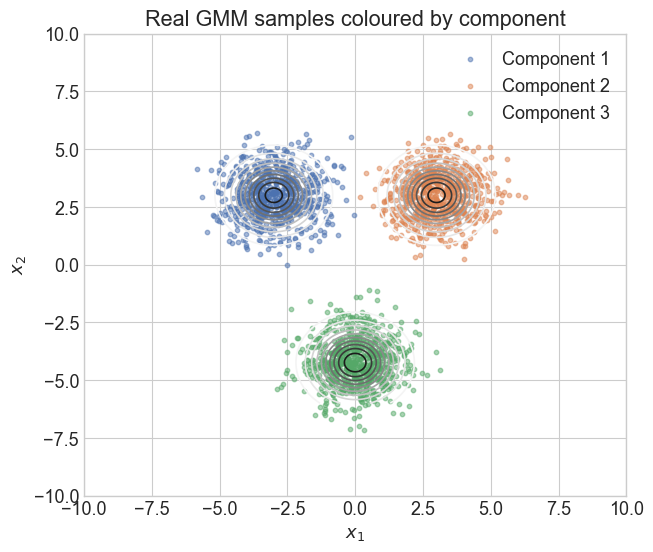

In [4]:
xs = np.linspace(-8, 8, 400)
ys = np.linspace(-6, 6, 300)
cmap = plt.get_cmap("Paired", len(mus_r))
Z_real = gmm_pdf_grid(xs, ys, mus_r, Sig_r, w_r)

plt.figure(figsize=(7,6))


for k in range(len(mus_r)):
    idx = labels_real == k
    plt.scatter(
        x_real[idx, 0],
        x_real[idx, 1],
        s=10,
        alpha=0.5,
        label=f"Component {k+1}",
        color=palette[k]
    )
plt.contour(xs, ys, Z_real, levels=12, linewidths=1.2)

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("Real GMM samples coloured by component")
plt.legend()
plt.savefig(IMAGE_DIR / "map-real-regions-contours.png", dpi=180, bbox_inches="tight")
plt.show()



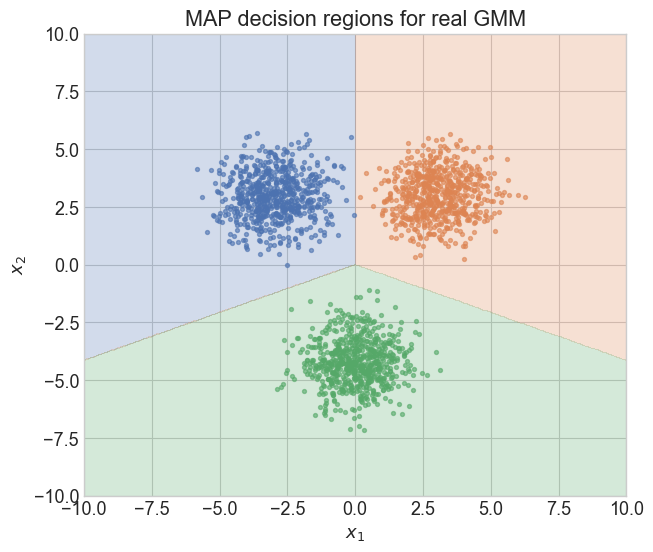

In [5]:
xs = np.linspace(*xlim, 500)
ys = np.linspace(*ylim, 500)

regions = map_regions(xs, ys, mus_r, Sig_r, w_r)

plt.figure(figsize=(7, 6))

palette = sns.color_palette("deep", len(mus_r))
cmap = ListedColormap(palette)
plt.contourf(xs, ys, regions, levels=len(mus_r)-1, alpha=0.25, cmap=cmap)
for k in range(len(mus_r)):
    idx = labels_real == k
    plt.scatter(
        x_real[idx, 0],
        x_real[idx, 1],
        s=8,
        alpha=0.6,
        color=palette[k]
    )

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("MAP decision regions for real GMM")
plt.xlim(xlim)
plt.ylim(ylim)
plt.show()



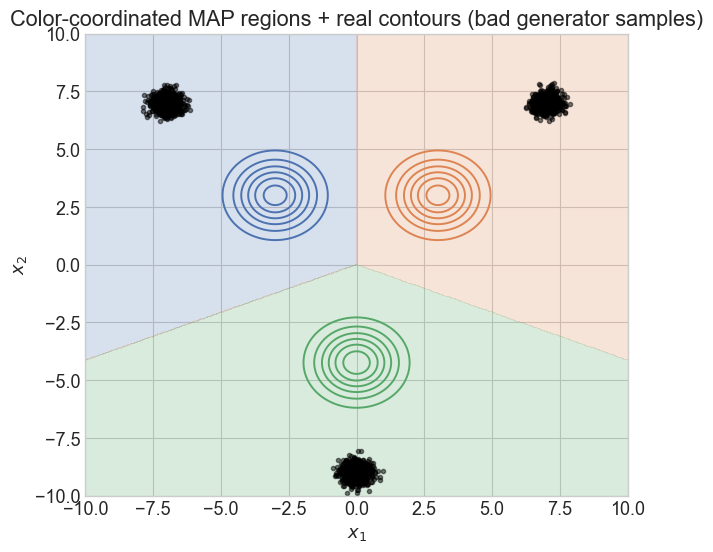

In [6]:
# Assumes already defined: sample_gmm, gmm_pdf_grid, map_regions, mus_r, Sig_r, w_r

rng = np.random.default_rng(42)

# Bad generator (kept intentionally off-support)
mus_bad = [np.array([-7.0, 7.0]), np.array([7.0, 7.0]), np.array([0.0, -np.sqrt(81)])]
Sig_bad = [0.08*np.eye(2), 0.08*np.eye(2), 0.08*np.eye(2)]
w_bad = np.array([1/3, 1/3, 1/3])
x_bad, _ = sample_gmm(1800, mus_bad, Sig_bad, w_bad, rng)

# Grid + real model visuals
xs = np.linspace(*xlim, 500)
ys = np.linspace(*ylim, 500)

regions = map_regions(xs, ys, mus_r, Sig_r, w_r)
Z_real = gmm_pdf_grid(xs, ys, mus_r, Sig_r, w_r)

# Color-coordinated palette
palette = sns.color_palette("deep", len(mus_r))
cmap = ListedColormap(palette)

plt.figure(figsize=(7, 6))

# MAP decision regions (background)
plt.contourf(xs, ys, regions, levels=np.arange(len(mus_r)+1)-0.5, alpha=0.22, cmap=cmap)

# Real density contours with matching colors
for k in range(len(mus_r)):
    Zk = w_r[k] * mvn_pdf_grid(xs, ys, mus_r[k], Sig_r[k])
    plt.contour(xs, ys, Zk, levels=6, linewidths=1.4, colors=[palette[k]])

# Bad generator samples only (no mean markers)
plt.scatter(x_bad[:, 0], x_bad[:, 1], s=9, alpha=0.5, color="black")

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("Color-coordinated MAP regions + real contours (bad generator samples)")
plt.savefig(IMAGE_DIR / "map-bad-generator-vs-real-contours.png", dpi=180, bbox_inches="tight")
plt.show()





In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, Math

# Match notebook look-and-feel
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 13,
    "figure.figsize": (7, 5),
})
palette = sns.color_palette("deep", 2)

# --- numerically stable SPD helpers ---
def sqrtm_spd(M, eps=1e-10):
    """Matrix square root for symmetric positive definite 2x2 matrices."""
    M = 0.5 * (M + M.T)
    w, V = np.linalg.eigh(M)
    w = np.clip(w, eps, None)
    return V @ np.diag(np.sqrt(w)) @ V.T

def cov_from_params(sig_x, sig_y, rho, eps=1e-8):
    """2D covariance from std-devs and correlation, with SPD guard rails."""
    rho = float(np.clip(rho, -0.995, 0.995))
    C = np.array(
        [[sig_x ** 2, rho * sig_x * sig_y],
         [rho * sig_x * sig_y, sig_y ** 2]],
        dtype=float,
    )
    return C + eps * np.eye(2)

def fid_gaussians(m_real, C_real, m_generated, C_generated):
    """FID = W2^2 between Gaussians N(m_real, C_real) and N(m_generated, C_generated)."""
    dm = np.asarray(m_real, dtype=float) - np.asarray(m_generated, dtype=float)
    mean_term = float(dm @ dm)

    A = sqrtm_spd(C_real)
    middle = sqrtm_spd(A @ C_generated @ A)
    cov_term = float(np.trace(C_real + C_generated - 2.0 * middle))
    return max(mean_term + cov_term, 0.0)

def gauss_pdf(X, Y, m, C, eps=1e-12):
    pos = np.dstack((X, Y))
    C = 0.5 * (C + C.T)
    Cinv = np.linalg.inv(C)
    det = max(float(np.linalg.det(C)), eps)
    diff = pos - np.asarray(m, dtype=float)
    expo = np.einsum("...i,ij,...j->...", diff, Cinv, diff)
    return np.exp(-0.5 * expo) / (2.0 * np.pi * np.sqrt(det))

slider_layout = widgets.Layout(width="420px")
slider_style = {"description_width": "0px"}

def make_slider(value, min_, max_, step, readout_format=".2f"):
    return widgets.FloatSlider(
        value=value,
        min=min_,
        max=max_,
        step=step,
        description="",
        readout=True,
        readout_format=readout_format,
        continuous_update=False,
        layout=slider_layout,
        style=slider_style,
    )

controls = {
    # p_real parameters
    "mrx": make_slider(0.0, -4.0, 4.0, 0.1, ".1f"),
    "mry": make_slider(0.0, -4.0, 4.0, 0.1, ".1f"),
    "srx": make_slider(1.0, 0.2, 3.0, 0.05, ".2f"),
    "sry": make_slider(0.7, 0.2, 3.0, 0.05, ".2f"),
    "rr": make_slider(0.3, -0.95, 0.95, 0.01, ".2f"),

    # p_generated parameters
    "mgx": make_slider(1.0, -4.0, 4.0, 0.1, ".1f"),
    "mgy": make_slider(1.0, -4.0, 4.0, 0.1, ".1f"),
    "sgx": make_slider(1.2, 0.2, 3.0, 0.05, ".2f"),
    "sgy": make_slider(1.5, 0.2, 3.0, 0.05, ".2f"),
    "rg": make_slider(-0.2, -0.95, 0.95, 0.01, ".2f"),
}

def latex_label(tex, width="130px"):
    out = widgets.Output(layout=widgets.Layout(width=width, height="28px"))
    with out:
        display(Math(tex))
    return out

def latex_header(tex, width="330px"):
    out = widgets.Output(layout=widgets.Layout(width=width, height="34px"))
    with out:
        display(Math(tex))
    return out

def labeled_row(tex, widget):
    return widgets.HBox(
        [latex_label(tex), widget],
        layout=widgets.Layout(align_items="center"),
    )

real_box = widgets.VBox([
    latex_header(r"p_{real}"),
    labeled_row(r"\mu_{r,1}", controls["mrx"]),
    labeled_row(r"\mu_{r,2}", controls["mry"]),
    labeled_row(r"\sigma_{r,1}", controls["srx"]),
    labeled_row(r"\sigma_{r,2}", controls["sry"]),
    labeled_row(r"\rho_r", controls["rr"]),
])

gen_box = widgets.VBox([
    latex_header(r"p_{gen}"),
    labeled_row(r"\mu_{g,1}", controls["mgx"]),
    labeled_row(r"\mu_{g,2}", controls["mgy"]),
    labeled_row(r"\sigma_{g,1}", controls["sgx"]),
    labeled_row(r"\sigma_{g,2}", controls["sgy"]),
    labeled_row(r"\rho_g", controls["rg"]),
])

out = widgets.Output()

def redraw(**kw):
    m_real = np.array([kw["mrx"], kw["mry"]], dtype=float)
    m_generated = np.array([kw["mgx"], kw["mgy"]], dtype=float)

    C_real = cov_from_params(kw["srx"], kw["sry"], kw["rr"])
    C_generated = cov_from_params(kw["sgx"], kw["sgy"], kw["rg"])

    fid = fid_gaussians(m_real, C_real, m_generated, C_generated)

    xs = np.linspace(-8, 8, 320)
    ys = np.linspace(-8, 8, 320)
    X, Y = np.meshgrid(xs, ys)

    Z_real = gauss_pdf(X, Y, m_real, C_real)
    Z_generated = gauss_pdf(X, Y, m_generated, C_generated)

    with out:
        out.clear_output(wait=True)
        plt.figure(figsize=(7, 6))

        plt.contour(X, Y, Z_real, levels=12, linewidths=1.2, colors=[palette[0]])
        plt.contour(X, Y, Z_generated, levels=12, linewidths=1.2, colors=[palette[1]])

        plt.scatter(m_real[0], m_real[1], s=45, color=palette[0], label=r"$\mu_{real}$")
        plt.scatter(m_generated[0], m_generated[1], s=45, color=palette[1], label=r"$\mu_{gen}$")

        plt.xlabel(r"$x_1$")
        plt.ylabel(r"$x_2$")
        plt.xlim(xlim)
        plt.ylim(ylim)
        plt.title(rf"$W_2^2(\mathcal{{N}}_{{real}}, \mathcal{{N}}_{{gen}}) = {fid:.4f}$")
        plt.legend()
        plt.show()

interactive = widgets.interactive_output(redraw, controls)
ui = widgets.VBox([
    out,
    widgets.HTML("<b>Parameters</b>"),
    widgets.HBox([real_box, gen_box], layout=widgets.Layout(gap="40px")),
])

display(ui, interactive)










Output()

In [8]:
from pathlib import Path
from ipywidgets.embed import embed_minimal_html

# Export standalone widget HTML for GitHub Pages
out_path = Path("../docs/assets/widgets/fid-widget.html")
out_path.parent.mkdir(parents=True, exist_ok=True)
embed_minimal_html(str(out_path), views=[ui, interactive], title="FID Widget")
print(f"Saved widget: {out_path.resolve()}")



Saved widget: /Users/lukepadmore/Projects/personal-blog/docs/assets/widgets/fid-widget.html


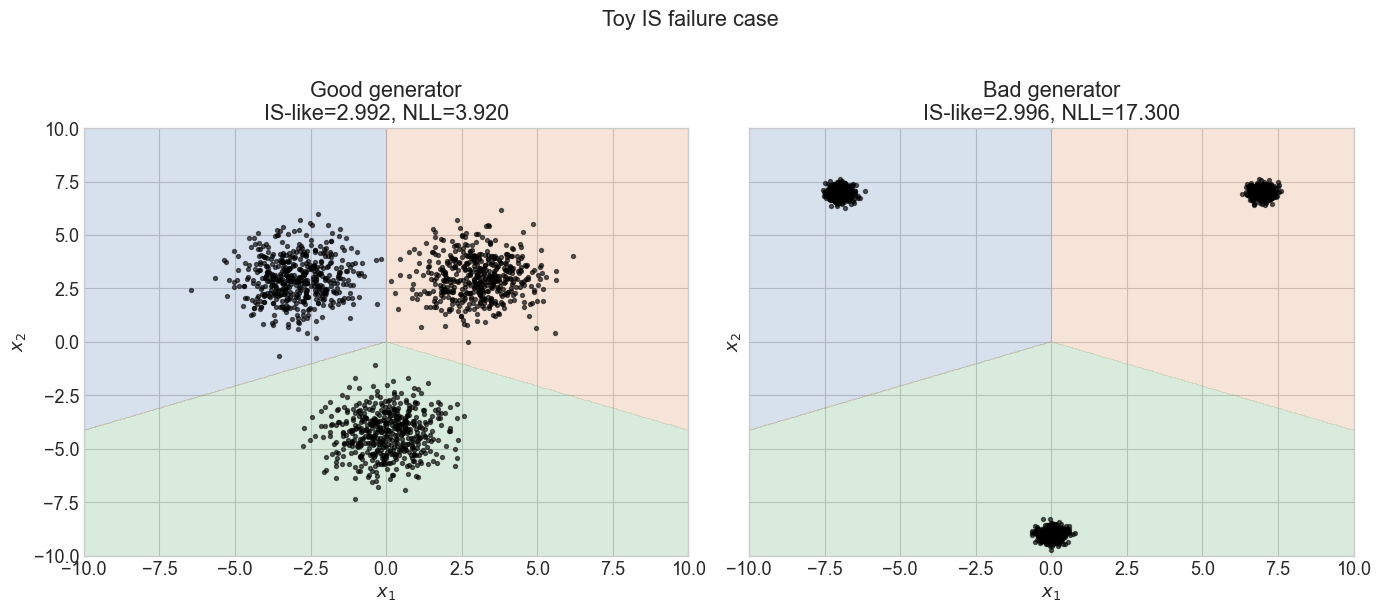

In [9]:
# Toy IS failure-case visual and save

def mvn_pdf_points(X, mu, Sigma):
    Si = np.linalg.inv(Sigma)
    det = np.linalg.det(Sigma)
    norm = 1.0 / (2.0 * np.pi * np.sqrt(det))
    d = X - mu
    q = np.einsum("ni,ij,nj->n", d, Si, d)
    return norm * np.exp(-0.5 * q)


def class_posteriors_under_real(X, mus, Sigmas, weights, eps=1e-12):
    comp = []
    for w, m, S in zip(weights, mus, Sigmas):
        comp.append(w * mvn_pdf_points(X, m, S))
    comp = np.stack(comp, axis=1)
    denom = np.sum(comp, axis=1, keepdims=True) + eps
    return comp / denom


def inception_like_score(X, mus, Sigmas, weights, eps=1e-12):
    p_yx = class_posteriors_under_real(X, mus, Sigmas, weights, eps=eps)
    p_y = np.mean(p_yx, axis=0, keepdims=True)
    kl = np.sum(p_yx * (np.log(p_yx + eps) - np.log(p_y + eps)), axis=1)
    return float(np.exp(np.mean(kl)))


def mean_neg_log_likelihood_under_real(X, mus, Sigmas, weights, eps=1e-12):
    px = np.zeros(X.shape[0])
    for w, m, S in zip(weights, mus, Sigmas):
        px += w * mvn_pdf_points(X, m, S)
    return float(-np.mean(np.log(px + eps)))


rng = np.random.default_rng(7)
N = 1500

x_good, _ = sample_gmm(N, mus_r, Sig_r, w_r, rng)

mus_bad = [np.array([-7.0, 7.0]), np.array([7.0, 7.0]), np.array([0.0, -np.sqrt(81)])]
Sig_bad = [0.05*np.eye(2), 0.05*np.eye(2), 0.05*np.eye(2)]
w_bad = np.array([1/3, 1/3, 1/3])
x_bad, _ = sample_gmm(N, mus_bad, Sig_bad, w_bad, rng)

is_good = inception_like_score(x_good, mus_r, Sig_r, w_r)
is_bad  = inception_like_score(x_bad,  mus_r, Sig_r, w_r)

nll_good = mean_neg_log_likelihood_under_real(x_good, mus_r, Sig_r, w_r)
nll_bad  = mean_neg_log_likelihood_under_real(x_bad,  mus_r, Sig_r, w_r)

xs = np.linspace(*xlim, 500)
ys = np.linspace(*ylim, 500)
regions = map_regions(xs, ys, mus_r, Sig_r, w_r)
cmap = ListedColormap(sns.color_palette("deep", len(mus_r)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax, X, ttl in [
    (axes[0], x_good, f"Good generator\nIS-like={is_good:.3f}, NLL={nll_good:.3f}"),
    (axes[1], x_bad,  f"Bad generator\nIS-like={is_bad:.3f}, NLL={nll_bad:.3f}"),
]:
    ax.contourf(xs, ys, regions, levels=np.arange(len(mus_r)+1)-0.5, alpha=0.22, cmap=cmap)
    ax.scatter(X[:,0], X[:,1], s=8, alpha=0.6, color="black")
    ax.set_title(ttl)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

plt.suptitle("Toy IS failure case", y=1.02)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "is-failure-case.png", dpi=180, bbox_inches="tight")
plt.show()



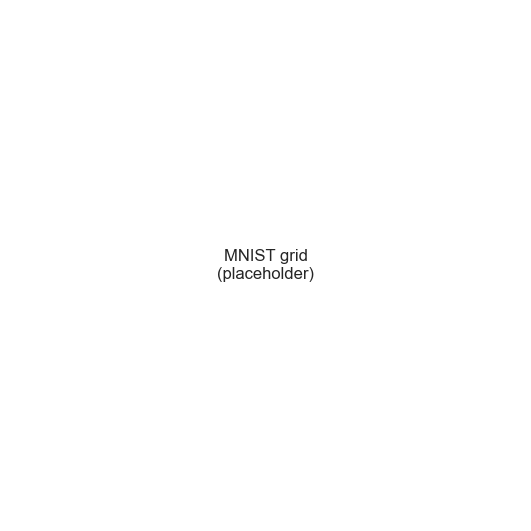

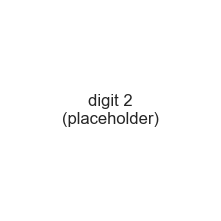

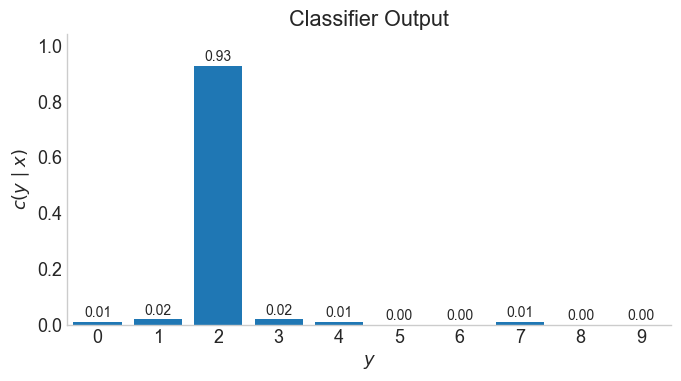

In [10]:
# Blog figures: MNIST grid + example digit and a classifier output bar chart
#
# Note: we use a global seaborn "whitegrid" style in this notebook, but for the
# classifier-output bar chart we explicitly disable gridlines to match the blog styling.

from pathlib import Path

# --- MNIST sample images ---
# Try to generate real MNIST images (requires torch/torchvision + download on first run).
# If unavailable, fall back to placeholders so the blog doesn't 404.
try:
    import torch  # noqa: F401
    from torchvision.datasets import MNIST
    from torchvision import transforms

    ds = MNIST(
        root=str(Path.home() / ".cache" / "torchvision"),
        train=False,
        download=True,
        transform=transforms.ToTensor(),
    )

    # Grid of MNIST samples (with labels)
    n = 16
    fig, axes = plt.subplots(4, 4, figsize=(6.5, 6.5))
    for ax, (img, y) in zip(axes.ravel(), [ds[i] for i in range(n)]):
        ax.imshow(img.squeeze(0), cmap="gray", vmin=0, vmax=1)
        ax.set_title(str(int(y)), fontsize=10)
        ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(IMAGE_DIR / "mnist_grid.png", dpi=180, bbox_inches="tight")
    plt.show()

    # Single example digit "2" (used in the classifier-output example)
    idx2 = next(i for i in range(len(ds)) if int(ds[i][1]) == 2)
    img2, _ = ds[idx2]
    fig, ax = plt.subplots(figsize=(2.4, 2.4))
    ax.imshow(img2.squeeze(0), cmap="gray", vmin=0, vmax=1)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(IMAGE_DIR / "mnist_digit_2.png", dpi=220, bbox_inches="tight")
    plt.savefig(IMAGE_DIR / "mnist-sample.png", dpi=220, bbox_inches="tight")  # backwards compat
    plt.show()

except Exception as e:
    # Placeholders
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.text(0.5, 0.5, "MNIST grid\n(placeholder)", ha="center", va="center", fontsize=12)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(IMAGE_DIR / "mnist_grid.png", dpi=180, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(2.4, 2.4))
    ax.text(0.5, 0.5, "digit 2\n(placeholder)", ha="center", va="center", fontsize=12)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(IMAGE_DIR / "mnist_digit_2.png", dpi=220, bbox_inches="tight")
    plt.savefig(IMAGE_DIR / "mnist-sample.png", dpi=220, bbox_inches="tight")
    plt.show()

# --- Classifier output bar chart ---
probs = np.array([0.01, 0.02, 0.93, 0.02, 0.01, 0.00, 0.00, 0.01, 0.00, 0.00])
classes = np.arange(10)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(classes, probs)
ax.set_xlim(classes.min() - 0.5, classes.max() + 0.5)
ax.set_xticks(classes)
ax.set_xticklabels([str(c) for c in classes])
ax.set_xlabel(r"$y$")
ax.set_ylabel(r"$c(y\mid x)$")
ax.set_ylim(0, max(0.05, probs.max() * 1.12))

# Style: no background grid (override seaborn whitegrid)
ax.grid(False)
ax.xaxis.grid(False)
ax.yaxis.grid(False)
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
sns.despine(ax=ax)

for c, p in zip(classes, probs):
    y_text = p + 0.005 if p > 0 else 0.005
    ax.text(c, y_text, f"{p:.2f}", ha="center", va="bottom", fontsize=10)
ax.set_title("Classifier Output")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "classifier-output-bars.png", dpi=180, bbox_inches="tight")
plt.show()


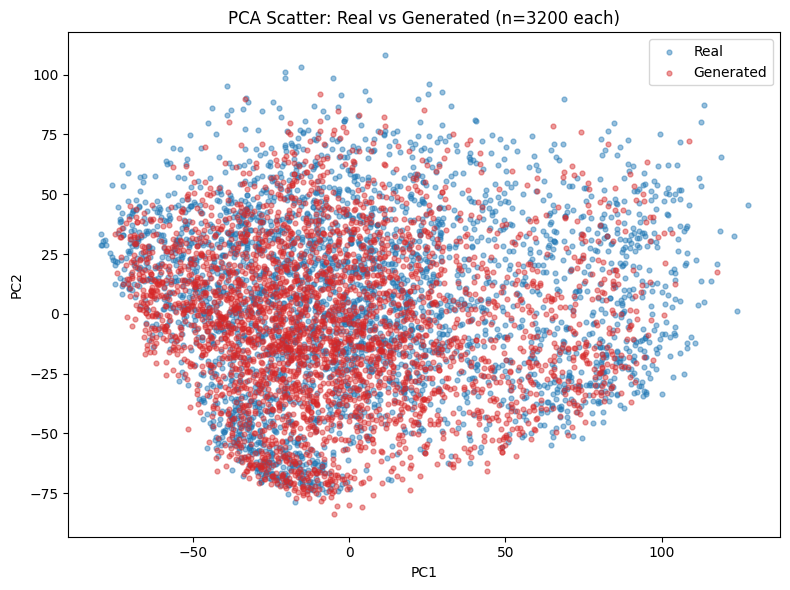

FID in PCA-2D (proxy): 234.7591


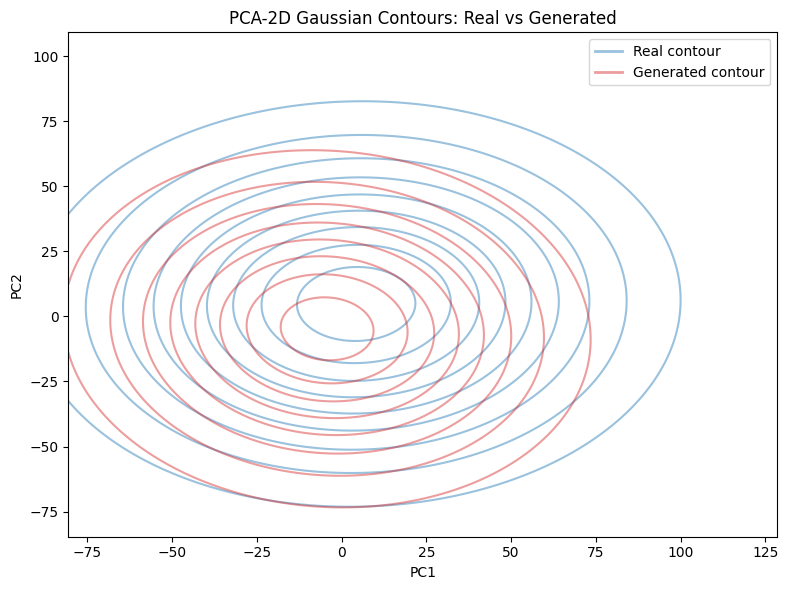

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import multivariate_normal
from scipy.linalg import sqrtm
from matplotlib.lines import Line2D

DATA_DIR = Path('data')
rng = np.random.default_rng(42)

zr = np.load(DATA_DIR / 'real_embeddings.npz')
zg = np.load(DATA_DIR / 'generated_embeddings.npz')
real_embeddings = zr[zr.files[0]]
generated_embeddings = zg[zg.files[0]]

TARGET_N = 3200
real_replace = len(real_embeddings) < TARGET_N
gen_replace = len(generated_embeddings) < TARGET_N

real_sample = real_embeddings[rng.choice(len(real_embeddings), size=TARGET_N, replace=real_replace)]
gen_sample = generated_embeddings[rng.choice(len(generated_embeddings), size=TARGET_N, replace=gen_replace)]

X = np.vstack([real_sample, gen_sample])
y = np.array(['Real'] * TARGET_N + ['Generated'] * TARGET_N)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
r2 = X_pca[y == 'Real']
g2 = X_pca[y == 'Generated']

# Scatter-only plot
plt.figure(figsize=(8, 6))
plt.scatter(r2[:, 0], r2[:, 1], s=12, alpha=0.45, label='Real', c='#1f77b4')
plt.scatter(g2[:, 0], g2[:, 1], s=12, alpha=0.45, label='Generated', c='#d62728')
plt.title('PCA Scatter: Real vs Generated (n=3200 each)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

# Fit Gaussians in PCA-2D
mu_r, mu_g = r2.mean(axis=0), g2.mean(axis=0)
cov_r = np.cov(r2, rowvar=False)
cov_g = np.cov(g2, rowvar=False)

covmean = sqrtm(cov_r @ cov_g)
if np.iscomplexobj(covmean):
    covmean = covmean.real
fid_2d = np.sum((mu_r - mu_g) ** 2) + np.trace(cov_r + cov_g - 2 * covmean)
print(f'FID in PCA-2D (proxy): {fid_2d:.4f}')

# Contour-only plot
xmin, xmax = X_pca[:, 0].min() - 1.0, X_pca[:, 0].max() + 1.0
ymin, ymax = X_pca[:, 1].min() - 1.0, X_pca[:, 1].max() + 1.0
xx, yy = np.meshgrid(np.linspace(xmin, xmax, 300), np.linspace(ymin, ymax, 300))
grid = np.dstack([xx, yy])

pdf_r = multivariate_normal(mean=mu_r, cov=cov_r).pdf(grid)
pdf_g = multivariate_normal(mean=mu_g, cov=cov_g).pdf(grid)

plt.figure(figsize=(8, 6))
cr = plt.contour(xx, yy, pdf_r, levels=10, colors='#1f77b4', linewidths=1.5, alpha=0.45)
cg = plt.contour(xx, yy, pdf_g, levels=10, colors='#d62728', linewidths=1.5, alpha=0.45)
plt.title('PCA-2D Gaussian Contours: Real vs Generated')
plt.xlabel('PC1')
plt.ylabel('PC2')

legend_handles = [
    Line2D([0], [0], color='#1f77b4', lw=2, alpha=0.45, label='Real'),
    Line2D([0], [0], color='#d62728', lw=2, alpha=0.45, label='Generated'),
]
plt.legend(handles=legend_handles, frameon=True)
plt.tight_layout()
plt.show()


